In [113]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as  sns 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , f1_score 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [72]:
df = pd.read_csv("Dry_Bean_Dataset.csv")
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [73]:
df.shape


(13611, 17)

In [74]:
df["Class"].unique()

<StringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str

there are 7 classes 

In [75]:
df["Class"].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

the data is balanced

<Axes: xlabel='Class', ylabel='Count'>

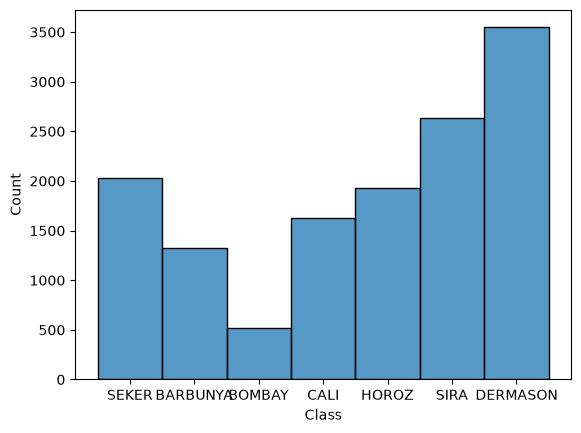

In [76]:

sns.histplot(x=df["Class"])



In [77]:
df.isna().sum().sum()

np.int64(0)

there is no missing values

In [78]:
features =df.select_dtypes(include="number").columns
features


Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')

In [79]:
for c in features :
    q1 = df[c].quantile(.25)
    q3 =df[c].quantile(.75)
    iqr = q3 -q1
    lower = q1 -1.5*iqr
    upper = q3 +1.5*iqr

    outliers =( (df[c]<lower )|(df[c]>upper)).sum()
    
    print(outliers)

551
500
379
569
473
843
550
526
275
778
91
109
533
0
195
767


In [80]:
for c in features :
    q1 = df[c].quantile(.25)
    q3 =df[c].quantile(.75)
    iqr = q3 -q1
    lower = q1 -1.5*iqr
    upper = q3 +1.5*iqr

    df = df[(df[c] >= lower) & (df[c] <= upper)]
    
   
    
   

In [81]:
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
23,31637,656.711,229.719255,175.510446,1.308864,0.645191,32045,200.702465,0.761823,0.987268,0.921842,0.873686,0.007261,0.002610,0.763327,0.999091,SEKER
24,31675,657.431,236.752632,171.210559,1.382816,0.690678,32009,200.822963,0.740936,0.989565,0.920929,0.848240,0.007474,0.002387,0.719510,0.994950,SEKER
29,31811,642.092,223.984683,180.917123,1.238051,0.589565,32052,201.253629,0.773877,0.992481,0.969600,0.898515,0.007041,0.002831,0.807329,0.999515,SEKER
31,31823,662.532,222.872689,181.894696,1.225284,0.577858,32274,201.291585,0.774848,0.986026,0.911040,0.903168,0.007004,0.002875,0.815713,0.999481,SEKER
32,31837,656.404,224.912554,180.439422,1.246471,0.596968,32238,201.335857,0.785246,0.987561,0.928538,0.895174,0.007065,0.002798,0.801336,0.998843,SEKER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,DERMASON
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,DERMASON
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,DERMASON
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653247,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,DERMASON


In [82]:
for c in features :
    q1 = df[c].quantile(.25)
    q3 =df[c].quantile(.75)
    iqr = q3 -q1
    lower = q1 -1.5*iqr
    upper = q3 +1.5*iqr

    outliers =( (df[c]<lower )|(df[c]>upper)).sum()
    
    print(outliers)

303
0
0
225
545
391
301
57
38
271
44
29
3
0
0
205


In [60]:
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class


In [83]:
x = df.drop(columns="Class")
y= df["Class"]

In [84]:
print(x.shape)
print(y.shape)

(10344, 16)
(10344,)


In [87]:
x_trian,x_test,y_train,y_test = train_test_split(x,y,test_size=.30,random_state=42,stratify=y)

In [88]:
X_train_ns70, X_test_ns70, y_train_ns70, y_test_ns70 = train_test_split(
    x, y,
    test_size=0.30,
    random_state=42
)

In [89]:
X_train_ns80, X_test_ns80, y_train_ns80, y_test_ns80 = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42
)

In [90]:
X_train_s80, X_test_s80, y_train_s80, y_test_s80 = train_test_split(
    x, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [92]:


model = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

In [93]:
model.fit(x_trian, y_train)

pred = model.predict(x_test)

acc = accuracy_score(y_test, pred)

print("Non-Stratified 70/30:", acc)

Non-Stratified 70/30: 0.8653350515463918


In [94]:
model.fit(X_train_s80, y_train_s80)

pred = model.predict(X_test_s80)

acc_s80 = accuracy_score(y_test_s80, pred)

print("Stratified 80/20:", acc_s80)

Stratified 80/20: 0.8453359110681489


In [95]:
model.fit(X_train_ns70, y_train_ns70)

pred = model.predict(X_test_ns70)

acc_ns70 = accuracy_score(y_test_ns70, pred)

print("Non-Stratified 70/30:", acc_ns70)

Non-Stratified 70/30: 0.8669458762886598


In [96]:
model.fit(X_train_ns80, y_train_ns80)

pred = model.predict(X_test_ns80)

acc_ns80 = accuracy_score(y_test_ns80, pred)

print("Non-Stratified 80/20:", acc_ns80)


Non-Stratified 80/20: 0.8569357177380377


In [97]:
max(acc_ns70,acc,acc_ns80,acc_s80)

0.8669458762886598

best accuracy when test size =.30 and non strayifed

In [99]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_trian, y_train)

y_pred = knn.predict(x_test)

accuracy_no_scaling = accuracy_score(y_test, y_pred)

print("Accuracy without scaling:", accuracy_no_scaling)

Accuracy without scaling: 0.7284149484536082


In [103]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_trian)
X_test_scaled = scaler.transform(x_test)
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled,y_train)
y_pred_scaled=knn_scaled.predict(X_test_scaled)

accuracy_scaling = accuracy_score(y_test, y_pred_scaled)

print("Accuracy with StandardScaler:", accuracy_scaling)



Accuracy with StandardScaler: 0.9101159793814433


scale affect on knn performance becauce distance bettween sample


In [105]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("F1-score:", f1)

Accuracy: 0.9101159793814433
F1-score: 0.910182954431829


In [ ]:
k_values = range(1, 26)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    

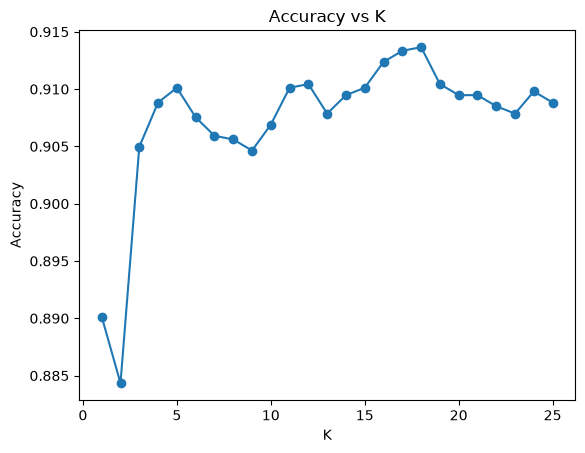

In [107]:


plt.plot(k_values, accuracies, marker='o')

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")

plt.show()

In [110]:
best_k = k_values[accuracies.index(max(accuracies))]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 18
Best Accuracy: 0.913659793814433


In [111]:
knn_euclidean = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='euclidean'
)

knn_euclidean.fit(X_train_scaled, y_train)

pred_euclidean = knn_euclidean.predict(X_test_scaled)

acc_euclidean = accuracy_score(y_test, pred_euclidean)

print("Euclidean Accuracy:", acc_euclidean)

Euclidean Accuracy: 0.913659793814433


In [112]:
knn_manhattan = KNeighborsClassifier(
    n_neighbors=best_k,
    metric='manhattan'
)

knn_manhattan.fit(X_train_scaled, y_train)

pred_manhattan = knn_manhattan.predict(X_test_scaled)

acc_manhattan = accuracy_score(y_test, pred_manhattan)

print("Manhattan Accuracy:", acc_manhattan)

Manhattan Accuracy: 0.9075386597938144


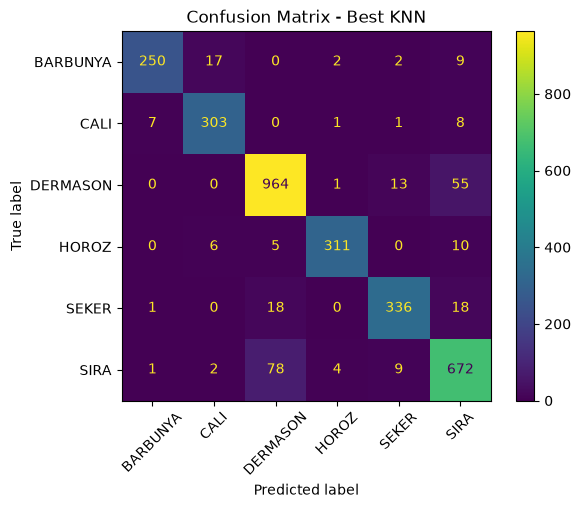

In [114]:
cm = confusion_matrix(y_test, pred_euclidean)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=knn_euclidean.classes_
)

disp.plot(xticks_rotation=45)

plt.title("Confusion Matrix - Best KNN")
plt.show()

In [116]:


cm = confusion_matrix(y_test, pred_euclidean)

for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:
            print(
                knn_euclidean.classes_[i],
                "misclassified as",
                knn_euclidean.classes_[j],
                ":",
                cm[i, j]
            )

BARBUNYA misclassified as CALI : 17
BARBUNYA misclassified as HOROZ : 2
BARBUNYA misclassified as SEKER : 2
BARBUNYA misclassified as SIRA : 9
CALI misclassified as BARBUNYA : 7
CALI misclassified as HOROZ : 1
CALI misclassified as SEKER : 1
CALI misclassified as SIRA : 8
DERMASON misclassified as HOROZ : 1
DERMASON misclassified as SEKER : 13
DERMASON misclassified as SIRA : 55
HOROZ misclassified as CALI : 6
HOROZ misclassified as DERMASON : 5
HOROZ misclassified as SIRA : 10
SEKER misclassified as BARBUNYA : 1
SEKER misclassified as DERMASON : 18
SEKER misclassified as SIRA : 18
SIRA misclassified as BARBUNYA : 1
SIRA misclassified as CALI : 2
SIRA misclassified as DERMASON : 78
SIRA misclassified as HOROZ : 4
SIRA misclassified as SEKER : 9
